# Tarea 3: Clasificación de galaxias con una CNN

En esta tarea trabajarán con una versión binaria del dataset [**Galaxy10 DECaLS**](https://astronn.readthedocs.io/en/latest/galaxy10.html). El objetivo es entrenar una red neuronal convolucional simple para clasificar imágenes de galaxias en dos clases:

- **Round Smooth Galaxies**
- **Barred Spiral Galaxies**

La idea no es obtener el mejor modelo posible, sino entender cómo una CNN aprende patrones visuales, cómo se evalúa su desempeño y en qué casos se equivoca.

## Consideraciones
- La tarea se hace en grupos máximos de **2 personas**
- Debe realizar todas las actividades descritas más abajo y responder y comentar lo que se pide.
- **La tarea se entrega el día viernes 07/08, 23:59 horas.**

--

## Actividades

1. **Exploración de datos**
   - Visualice imágenes aleatorias de ambas clases
   - ¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?
   - ¿Qué características espera que pueda aprender la red?
   - ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?
     
2. **Preparación de datos**
   - Separe los datos en conjuntos de entrenamiento, validación y test
   - Justifique brevemente por qué es importante tener estos tres conjuntos
     
3. **Arquitectura de la red** (ver más abajo **"Guía para diseñar la CNN"**)
   - Entrene una CNN simple para clasificación binaria
   - Describa la arquitectura utilizada e indique:
        - cuántas capas convolucionales usó
        - qué función de activación escogió
        - si usó pooling, dropout u otra técnica
        - qué función de pérdida utilizó
     - Justifique brevemente estas elecciones. Para esto, puede servir describir el proceso de prueba y error con otras arquitecturas, mostrar y comparar desempeños, o su intuición al elegir la arquitectura  
       
4. **Entrenamiento**
   - Grafique las curvas de pérdida y accuracy para entrenamiento y validación
   - A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable
     
5. **Evaluación del modelo**
   - Evalúe el modelo en el conjunto de test usando:
        - accuracy
        - matriz de confusión
        - precision, recall y F1-score
    - ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique
      
6. **Análisis de errores**
   - Muestre algunos ejemplos de imágenes mal clasificadas. ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
   - Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución

7. **Comentario final**
   - A partir de sus resultados, discuta brevemente si el modelo parece estar aprendiendo diferencias morfológicas reales entre galaxias suaves y galaxias espirales barradas, o si podría estar usando otros patrones de las imágenes.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

## Configuración de sesión de colab
Debemos trabajar en Google Colab, que tiene la ventaja de tener tensorflow y Keras ya instalado y además levanta un servidor de GPU suficiente para el propósito de esta tarea.  
Para activarlo, debe ir a `Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU`.

Si lo cambió exitosamente, el siguiente comando no debiera ser un array vacío, sino indicar que  `device_type=GPU`

In [2]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#monte su cuenta de google drive para trabajar en una carpeta ahí. Le pedirá autentificación
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Los datos de Galaxy10 DECaLS vienen de un dataset de Kaggle, con las clases que estudiaremos ya seleccionadas. Más detalles [acá.](https://www.kaggle.com/datasets/anth0nym/galaxy10-decals-fork-dataset)

In [4]:
path = "/content/drive/MyDrive/BigData/Binary_2_5_dataset.h5" #cambie este path al correspondiente suyo, en su carpeta drive

with h5py.File(path, "r") as f:
    images = np.array(f["images"])
    labels = np.array(f["labels"], dtype="int32")

print(images.shape)
print(labels.shape)

classes, counts = np.unique(labels, return_counts=True)
for c, n in zip(classes, counts):
    print(c, n)

(4688, 256, 256, 3)
(4688,)
0 2645
1 2043


## Estructura de los datos

El dataset contiene **4688 imágenes de galaxias**, cada una con tamaño **256 × 256 píxeles** y **3 canales de color**. Por eso, el arreglo de imágenes tiene la forma:

(4688, 256, 256, 3)

In [5]:
#X

In [6]:
X = images
y = labels.astype("int32")

Para visualizar las imágenes

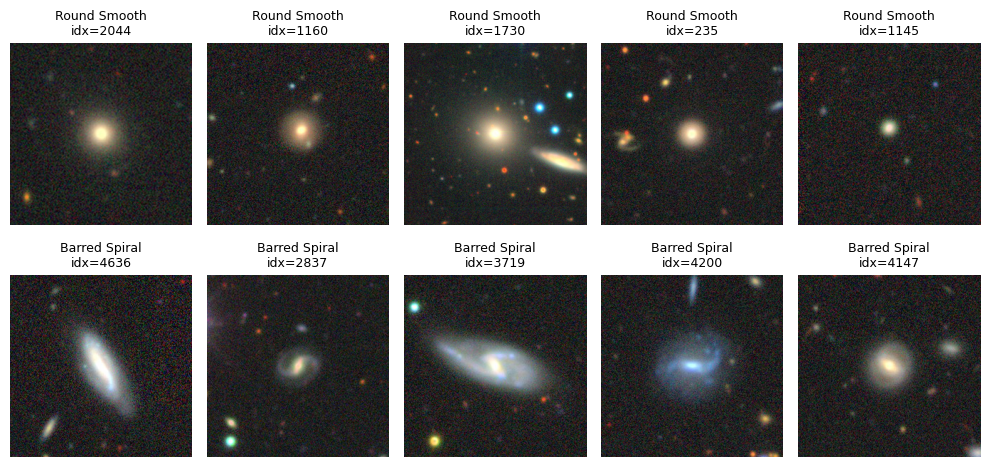

In [7]:
class_names = {
    0: "Round Smooth",
    1: "Barred Spiral"
}

rng = np.random.default_rng(42)  # semilla para que sea reproducible

#Visualiza 5 imágenes aleatorias de cada clase

plt.figure(figsize=(10, 5))

for class_id in [0, 1]:
    idxs = np.where(labels == class_id)[0]
    sample_idxs = rng.choice(idxs, size=5, replace=False)

    for j, idx in enumerate(sample_idxs):
        plt.subplot(2, 5, class_id * 5 + j + 1)
        plt.imshow(images[idx])
        plt.title(f"{class_names[class_id]}\nidx={idx}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()


*   ¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?

1.R: La Round Smooth es mas circular y no tiene brazos, la Barred Spiral es mas eliptica y tiene brazos.   
*   ¿Qué características espera que pueda aprender la red?

2.R: Identificar cuando tiene brazos una galaxia y lograr ver la forma de la galaxia.  
*   ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?

3.R: La proporcion de las galaxias Round Smooth sobre el total es de 0.5642, el accuracy es de 56.42%

In [8]:
2645/4688

0.5642064846416383

## Sets de entrenamiento, validación y prueba

Divida el dataset en entrenamiento, validación y prueba. Verifique que la fracción de las clases es similar en todos los sets

In [9]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=25
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=25
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("Train classes:", np.unique(y_train, return_counts=True))
print("Val classes:", np.unique(y_val, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

Train: (3000, 256, 256, 3) (3000,)
Val: (750, 256, 256, 3) (750,)
Test: (938, 256, 256, 3) (938,)
Train classes: (array([0, 1], dtype=int32), array([1693, 1307]))
Val classes: (array([0, 1], dtype=int32), array([423, 327]))
Test classes: (array([0, 1], dtype=int32), array([529, 409]))




*   Justifique brevemente por qué es importante tener estos tres conjuntos

R: El conjunto de entrenamiento es el que ajusta los pesos de la red. El de
validación se usa durante el entrenamiento para monitorear el desempeño en
datos no vistos y tomar decisiones de diseño; como esas decisiones se
toman mirándolo, el modelo termina indirectamente ajustado a él. Por eso se reserva un tercer conjunto de test, que no se toca hasta el final, y que entrega la única estimación no sesgada de cómo se comportaría el modelo con galaxias nuevas.



## Guía para diseñar la CNN

Para esta tarea deben proponer una red convolucional simple usando
Keras. No existe una única arquitectura correcta, pero su diseño debe estar justificado.

Una CNN para este problema debería incluir, al menos:

- capas convolucionales, para aprender patrones locales en la imagen;
- alguna forma de reducción espacial, como `MaxPooling2D`;
- una parte final densa o de agregación, para hacer la clasificación;
- una capa de salida adecuada para clasificación binaria.

<figure>
  <img src="https://www.astroml.org/astroML-notebooks/_images/fig_cnn_1.png" alt="ejemplo CNN" width="500" height="300">
  <figcaption>Ejemplo arquitectura CNN</figcaption>
</figure>




Al diseñar la arquitectura, responda:

1. ¿Cuántas capas convolucionales usará?
   ¿Por qué cree que esa profundidad es suficiente para este problema?

R: 4, debido a que las galxias tienen desde estructuras visualmente muy basicas a otras mas complejas.

2. ¿Cuántos filtros tendrá cada capa convolucional?  
   ¿Usará el mismo número de filtros en todas las capas o aumentará la cantidad de filtros en capas más profundas? Justifique.

R: 32, 64, 128 y 256, No, los filtros seran progresivamente mas, para ver detalles mas sutiles.

3. ¿Qué función de activación usará en las capas internas?  
   ¿Por qué?

R: Se usa la función de activación 'relu', ya que es muy eficiente porque transforma los valores negativos a cero y deja intactos los positivos.

4. ¿Usará `MaxPooling2D` u otra forma de reducir el tamaño espacial de los mapas de activación?  
   ¿Qué ventaja tiene esto?

R: Use el `MaxPooling2D`, las ventajas que tiene es que extrae únicamente la señal visual más intensa de una pequeña región y esto reduce el ancho y alto de los mapas a la mitad.

5. ¿Usará `Flatten` o `GlobalAveragePooling2D` antes de la parte densa?  
   ¿Qué diferencia hay entre ambas opciones?

R: Use `GlobalAveragePooling2D`, `Flatten` aplasta las matrices tridimensionales en un vector gigante manteniendo la información de dónde estaba cada píxel y `GlobalAveragePooling2D` calcula un solo promedio por cada filtro esto reduce los parámetros drásticamente y estabiliza el modelo.

6. ¿Incluirá alguna técnica para reducir overfitting, como `Dropout` o `EarlyStopping`?  
   ¿Por qué podría ser necesaria en este dataset?

R: Se usa `EarlyStopping` y `Dropout`, debido que sino memoriza el ruido de fondo para eso es util utilizar `Dropout`  en este caso se uso un `Dropout` bastante sutil de 0.2.

7. ¿Qué función de activación debe tener la capa de salida?  
   ¿Por qué esa elección es adecuada para una clasificación binaria?

R: Debe tener la función sigmoid, ya que comprime cualquier valor que reciba de la red hacia un rango estrictamente entre 0 y 1.

8. ¿Qué función de pérdida usará?  
   Justifique su elección considerando que el problema tiene dos clases.

R: Use `binary_crossentropy`, ya que está diseñada específicamente para trabajar en conjunto con la activación Sigmoid en problemas binarios.

## Plantilla de la red
Complete de acuerdo a su elección de la arquitectura. Debe reemplazar los __ con los valores correspondientes

La capa después de entrada es una capa para normalizar los imágenes. Esto ya que debemos escalar los datos cuando calculamos gradientes, asi la red es más estable, y no depende de los valores de la features.
 Conviene hacerlo en la red misma en vez hacerlo antes, porque en este caso sólo lo hará para las imágenes del batch (los ejemplos que toma para calcular los forward pass y backpropagation). Esto evita que el servidor use todo el RAM disponible


 --
 ### [Bloque convolucional](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D)

```python
layers.Conv2D(____, kernel_size=____, activation=____)
```

- **Primer `____`**: cantidad de filtros de la capa.
- **`kernel_size`**: tamaño de la ventana convolucional.
- **`activation`**: función de activación de la capa.

### [Pooling final](https://keras.io/api/layers/pooling_layers/)

```python
layers.________________()
```

Capa de pooling que reduce el mapa de características a un vector, antes de pasar a las capas densas.

### Capa densa intermedia

```python
layers.Dense(____, activation=____)
```

- **Número de neuronas** de la capa.
- **`activation`**: función de activación.

### Capa de salida

```python
layers.Dense(____, activation=____)
```

- **Número de neuronas**: debe ser consistente con el tipo de problema (clasificación binaria) y con el `loss` ya definido en el `compile`.
- **`activation`**: debe ser coherente con esa misma decisión.

In [10]:
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)), #capa de entrada, cantidad de neuronas igual a la cantidad de features
    layers.Rescaling(1./255), #capa de normalización


    # Bloque convolucional 1
    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Bloque convolucional 2
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Bloque convolucional 3
    layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Bloque convolucional 4
    layers.Conv2D(256, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Bloque convolucional, agregue máximo 4
    # layers.Conv2D(____, kernel_size=____, activation=____),
    # layers.MaxPooling2D(),

    # Parte final de clasificación, capa de pooling
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'), #capa densa fully connecte


    layers.Dropout(0.2), # Apaga el 20% de las conexiones

    # Capa de salida
    layers.Dense(1, activation='sigmoid')
])

# Control manual del optimizador con pasos más precisos
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary() #resumen de la arquitectura de la red



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,929 (1.54 MB)

 Trainable params: 404,929 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#regularizacion early stopping de la red https://keras.io/api/callbacks/early_stopping/
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# para correr la red
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40, #puede modificar este valor
    batch_size=32,#puede modificar este valor
    callbacks=[early_stop]
)

Epoch 1/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 189ms/step - accuracy: 0.5783 - loss: 0.6806 - val_accuracy: 0.5760 - val_loss: 0.6754
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.7553 - loss: 0.5278 - val_accuracy: 0.7413 - val_loss: 0.5292
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.7817 - loss: 0.4648 - val_accuracy: 0.7760 - val_loss: 0.4925
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8027 - loss: 0.4456 - val_accuracy: 0.7987 - val_loss: 0.4607
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8000 - loss: 0.4432 - val_accuracy: 0.7987 - val_loss: 0.4410
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.8083 - loss: 0.4281 - val_accuracy: 0.7920 - val_loss: 0.4604
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8190 - loss: 0.4125 - val_accuracy: 0.8080 - val_loss: 0.4264
Epoch 8/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.8243 - loss: 0.4032 - val_accuracy: 0.7893 

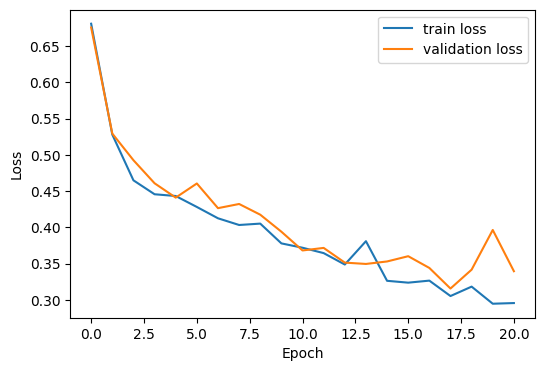

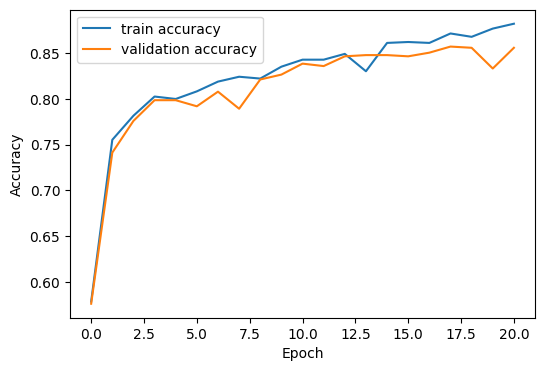

In [12]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



*   A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable.

R: No se observa overfitting ni tampoco underfitting por lo que consideramos que es un entrenamiento razonable.




In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8742 - loss: 0.3060
Test loss: 0.3060
Test accuracy: 0.8742


#### Genere la matriz de confusión y las métricas

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


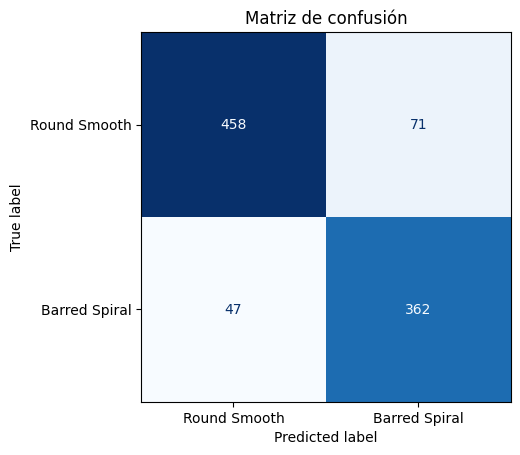

               precision  recall  f1-score
Round Smooth      0.9069  0.8658    0.8859
Barred Spiral     0.8360  0.8851    0.8599
weighted avg      0.8760  0.8742    0.8745

Accuracy:0.8742


In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd
from sklearn.metrics import accuracy_score
y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5)

labels_txt = [class_names[0], class_names[1]]

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=labels_txt).plot(cmap="Blues",colorbar=False)
plt.title("Matriz de confusión")
plt.show()

# 1. Pedirle a sklearn que entregue el reporte como diccionario
report_dict = classification_report(y_test, y_pred, target_names=labels_txt, output_dict=True)

# 2. Convertir a tabla, eliminar las filas/columnas no deseadas en la misma línea, y redondear
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.drop(index=['macro avg','accuracy'], columns=['support'])
df_report = df_report.round(4)

# 3. Mostrar la tabla final
print(df_report)
print()
print(f'Accuracy:{accuracy_score(y_test, y_pred):.4f}')



*   ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique

R: No, el accuracy por sí solo no es suficiente. Debido a que el conjunto de prueba está desbalanceado, un buen accuracy global podría ocultar que el modelo simplemente estuviera prediciendo la clase mayoritaria. Para confirmar que la red realmente aprendió a distinguir las morfologías, es muy importante revisar métricas individuales como el Recall (0.8658) y el F1-score (0.8859) de la clase minoritaria. Además la matriz de confusión permite observar si los errores son equilibrados o si presenta un sesgo hacia alguna de las clases en particular.




#### Revise algunos ejemplos de galaxias mal clasificadas

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Total de imágenes mal clasificadas: 118


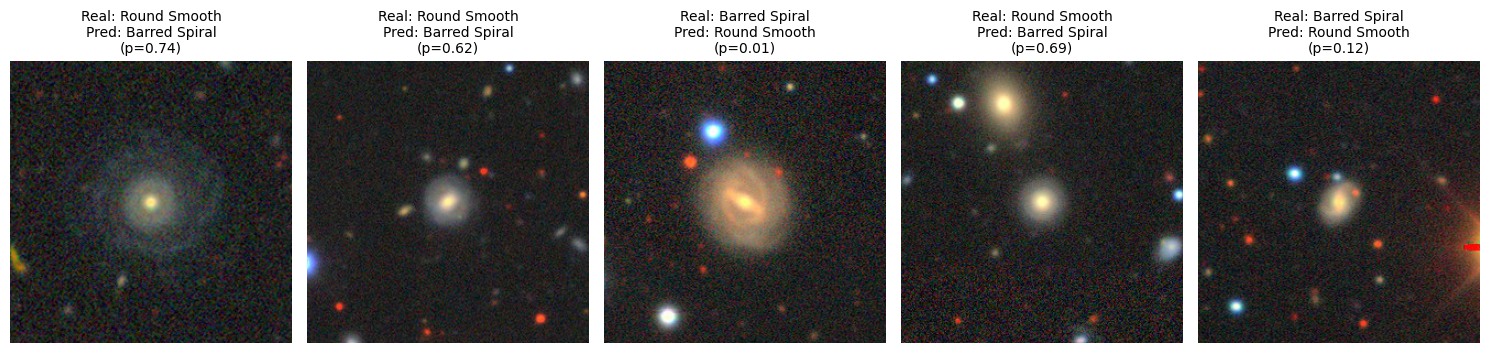

In [15]:
import random

y_prob_flat = model.predict(X_test).flatten()
y_pred_flat = (y_prob_flat >= 0.5).astype(int)
y_test_flat = y_test.flatten()

# 2. Encontrar TODOS los índices donde el modelo falló
errores_indices = np.where(y_pred_flat != y_test_flat)[0]

print(f"Total de imágenes mal clasificadas: {len(errores_indices)}")

# 3. Elegir 5 imágenes al azar de la lista de errores
muestras_azar = random.sample(list(errores_indices), 5)

# 4. Graficar los 5 errores elegidos
plt.figure(figsize=(15, 4))
for i, idx in enumerate(muestras_azar):
    plt.subplot(1, 5, i + 1)

    img = X_test[idx]
    plt.imshow(img)

    # Extraemos las etiquetas y la probabilidad
    etiqueta_real = class_names[int(y_test_flat[idx])]
    etiqueta_pred = class_names[int(y_pred_flat[idx])]
    prob = float(y_prob_flat[idx])

    plt.title(f"Real: {etiqueta_real}\nPred: {etiqueta_pred}\n(p={prob:.2f})", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()



*   ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?

R: La verdad parecen mas errores del modelo que casos morfológicamente ambiguos aunque si que hay casos hasta donde a mi me cuesta diferenciar que tipo de galaxias son.




#### Conclusiones y comentarios finales

R: A partir de los resultados obtenidos, hay evidencia sólida para afirmar que el modelo sí está aprendiendo diferencias morfológicas reales, aunque sigue siendo vulnerable a la interferencia de otros patrones visuales.